In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def load_dcors(path_dict: dict[str, str]):
    data_dict = {}
    for k, v in path_dict.items():
        with open(v) as f:
            data_dict[k] = json.load(f)

    return data_dict


In [5]:
dcors = {
    "None": "logs/topk.json",
    "Latent": "logs/top_latent.json",
    "Recon": "logs/top_recon.json",
    "Random": "logs/random_latent.json",
    # "None_norm": "logs/topk_norm.json",
    # "Latent_norm": "logs/topk_latent_norm.json",
    # "Recon_norm": "logs/topk_dcor_recon_norm.json",
}

dcors_data = load_dcors(dcors)

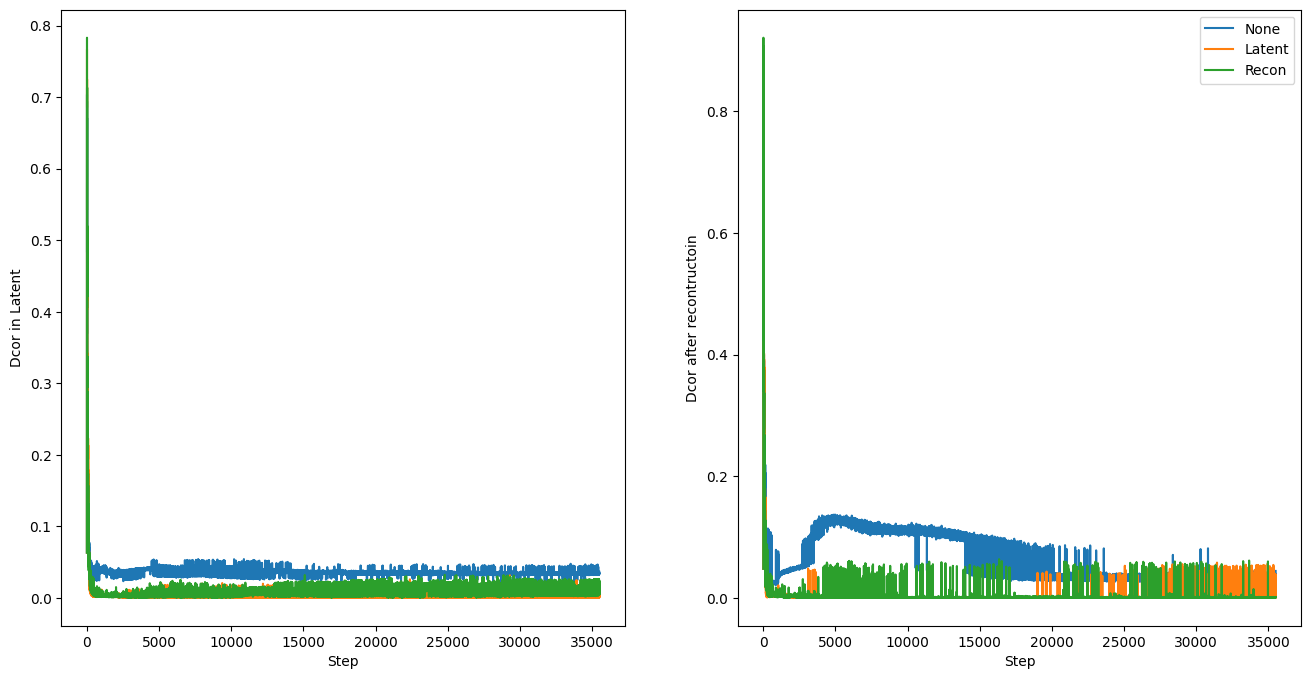

In [5]:
# Plot every step

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
axs[0].set_xlabel("Step")
axs[0].set_ylabel("Dcor in Latent")
axs[1].set_xlabel("Step")
axs[1].set_ylabel("Dcor after recontructoin")
for name, data in dcors_data.items():
    axs[0].plot([ step for epoch in  data['top_latent'] for step in  epoch], label=name)
    axs[1].plot([ step for epoch in  data['top_recon'] for step in  epoch], label=name)
    plt.legend()

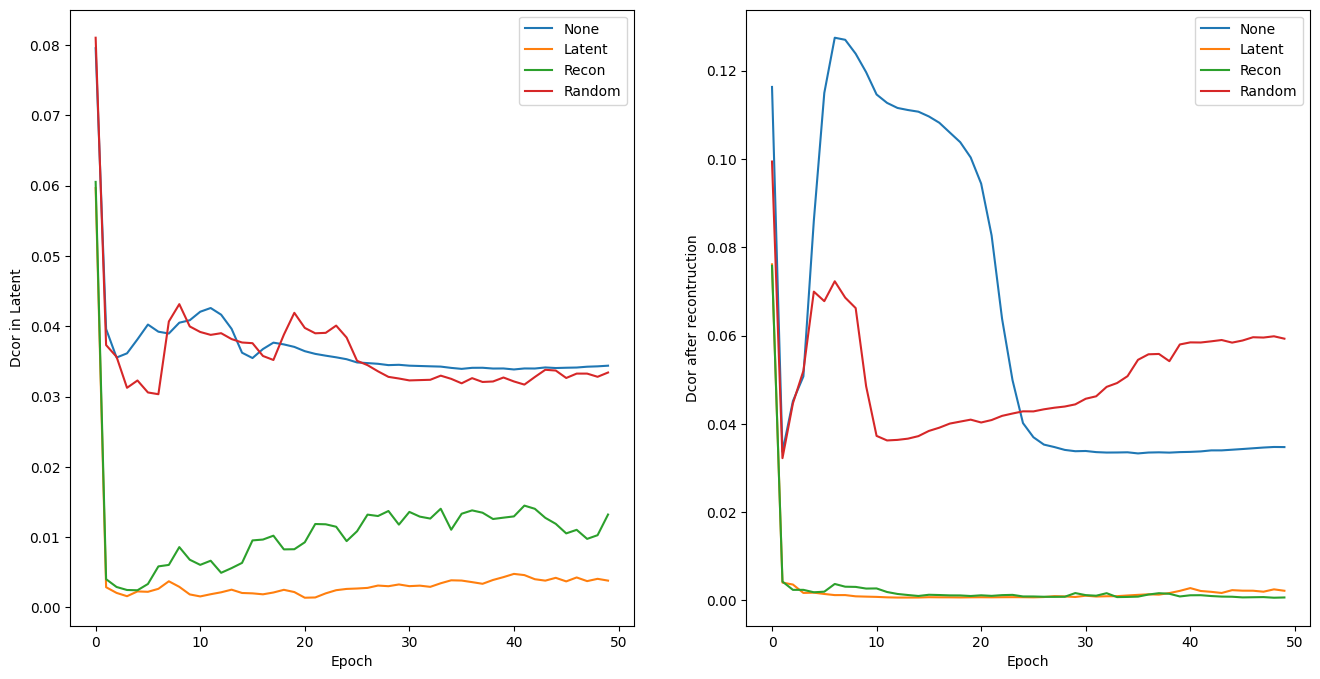

In [8]:
# Plot over epoch

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Dcor in Latent")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Dcor after recontruction")
for name, data in dcors_data.items():
    axs[0].plot([np.mean(epoch) for epoch in data["top_latent"]], label=name)
    axs[1].plot([np.mean(epoch) for epoch in data["top_recon"]], label=name)
    axs[0].legend()
    axs[1].legend()